# Brazil Quantum Camp

**Bloco 2, aula 6** - Otimização quântica II

In [1]:
! pip install qiskit qiskit-aer pylatexenc -q

In [2]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from functools import partial
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.optimize import minimize

 # Funções auxiliares

In [3]:
def plot_graph(
    graph: list[(int, int)],
    cut: list[int] | None = None,
    n: int | None = None,
):
    if cut is None:
        if n is None:
            raise ValueError("either cut or n must be provided")
        cut = [None] * n
    G = nx.Graph()
    G.add_edges_from(graph)
    node_color = [
        {"0": "#F9F06B", "1": "#1A5FB4"}.get(group, "#9A9996") for group in cut
    ]
    edge_color = []
    for u, v in G.edges():
        if cut[u] != cut[v]:
            edge_color.append("#E01B24")
        else:
            edge_color.append("gray")
    nx.draw(
        G,
        nx.spring_layout(G, seed=42),
        with_labels=True,
        node_color=node_color,
        node_size=2000,
        edge_color=edge_color,
        font_weight="bold",
        width=2,
    )
    plt.show()


def pauli_label(n, z_indices=None, x_indices=None):
    label = ["I"] * n
    for i in z_indices or []:
        label[n - 1 - i] = "Z"
    for i in x_indices or []:
        label[n - 1 - i] = "X"
    return "".join(label)


def expectation_value(qc, op):
    sv = Statevector.from_instruction(qc)
    return float(np.real(sv.expectation_value(op)))


class SampleResult:
    def __init__(self, counts, n):
        self._counts = counts
        self._n = n

    def get(self):
        return self._counts

    def histogram(self):
        labels = {f"|{k:0{self._n}b}>": v for k, v in self._counts.items()}
        return plot_histogram(labels)


def sample_circuit(qc, shots=100):
    qc_m = qc.copy()
    qc_m = qc_m.decompose(reps=2)
    qc_m.measure_all()
    sim = AerSimulator()
    result = sim.run(qc_m, shots=shots).result()
    counts = result.get_counts()

    int_counts = {}
    for bits, count in counts.items():
        bits = bits.replace(" ", "")[::-1]
        int_counts[int(bits, 2)] = count
    return SampleResult(int_counts, qc.num_qubits)


def draw(build_fn, n, fold=None, decompose_reps=1):
    qc = QuantumCircuit(n)
    build_fn(qc, list(range(n)))
    if decompose_reps is not None and decompose_reps > 0:
        qc = qc.decompose(reps=decompose_reps)
    return qc.draw("mpl", fold=fold, plot_barriers=False)


def get_cost(state, h_op):
    op = h_op() if callable(h_op) else h_op
    sv = Statevector.from_label(state[::-1])
    return float(np.real(sv.expectation_value(op)))

# QAOA Max-Cut

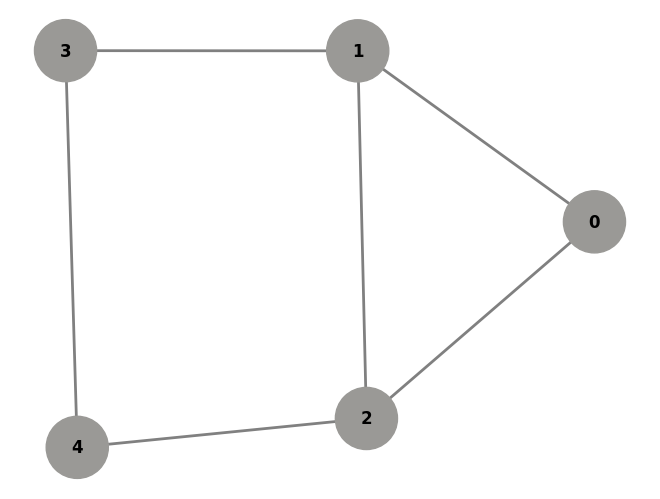

In [4]:
graph = [(0, 1), (0, 2), (1, 2), (1, 3), (2, 4), (3, 4)]
n = 5
plot_graph(graph, n=n)

## Hamiltoniano do Problema

$$H_C = -\frac{1}{2}\sum_{(a,\ b)\in E} 1-Z_aZ_b$$

In [5]:
def cost_h(graph, n):
    labels = []
    coeffs = []

    labels.append("I" * n)
    coeffs.append(-0.5 * len(graph))

    for a, b in graph:
        labels.append(pauli_label(n, z_indices=[a, b]))
        coeffs.append(0.5)

    return SparsePauliOp.from_list(list(zip(labels, coeffs)))

## Hamiltoniano de Mistura

$$H_M = \sum_kX_k$$

In [6]:
def mixer_h(n):
    labels = []
    coeffs = []
    for i in range(n):
        labels.append(pauli_label(n, x_indices=[i]))
        coeffs.append(1.0)
    return SparsePauliOp.from_list(list(zip(labels, coeffs)))

## Circuito Parametrizado

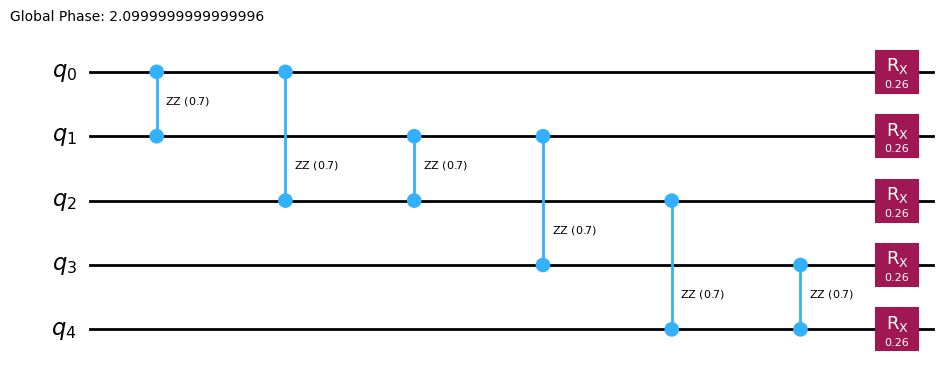

In [7]:
def qaoa_layer(graph, qc, qubits, gamma, beta):
    n = len(qubits)
    cost_op = cost_h(graph, n)
    mixer_op = mixer_h(n)

    qc.append(PauliEvolutionGate(cost_op, time=gamma), qubits)
    qc.barrier()
    qc.append(PauliEvolutionGate(mixer_op, time=beta), qubits)


draw(partial(qaoa_layer, graph, gamma=0.7, beta=0.13), n)

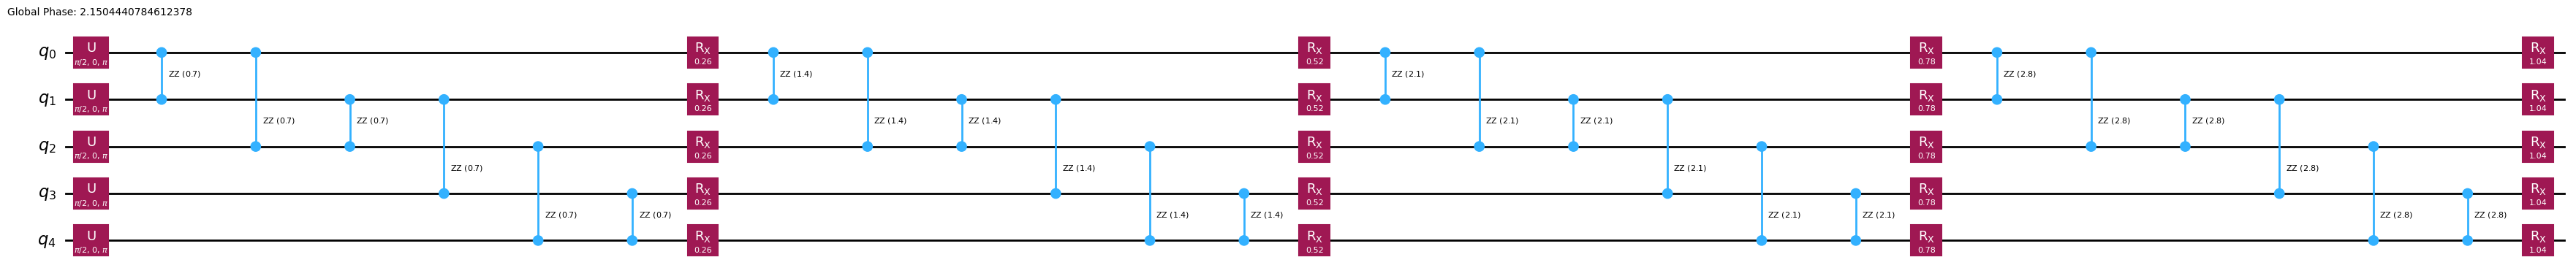

In [8]:
def ansatz(graph, qc, qubits, gamma, beta):
    qc.h(qubits)
    for g, b in zip(gamma, beta):
        qaoa_layer(graph, qc, qubits, g, b)


p = 4
draw(
    partial(
        ansatz,
        graph,
        gamma=[0.7 * i for i in range(1, p + 1)],
        beta=[0.13 * i for i in range(1, p + 1)],
    ),
    n,
    fold=-1,
)

## Otimizando os parâmetros    

In [9]:
def objective(graph, n, parameters, final=False):
    p = len(parameters) // 2
    gamma = parameters[p:]
    beta = parameters[:p]

    qc = QuantumCircuit(n)
    ansatz(graph, qc, list(range(n)), gamma, beta)

    if final:
        return sample_circuit(qc, 100)

    op = cost_h(graph, n)
    return expectation_value(qc, op)

In [10]:
p = 4
parameters = [0.5 for _ in range(2 * p)]

res = minimize(
    partial(objective, graph, n),
    parameters,
    method="COBYLA",
)

res

/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


 message: Return from COBYLA because the objective function has been evaluated MAXFUN times.
 success: False
  status: 3
     fun: -4.646037005624132
       x: [ 6.494e-01 -1.361e+00 -2.961e-01  7.126e-01  1.147e+00
            1.169e+00 -6.218e-01 -1.018e+00]
    nfev: 1000
   maxcv: 0.0

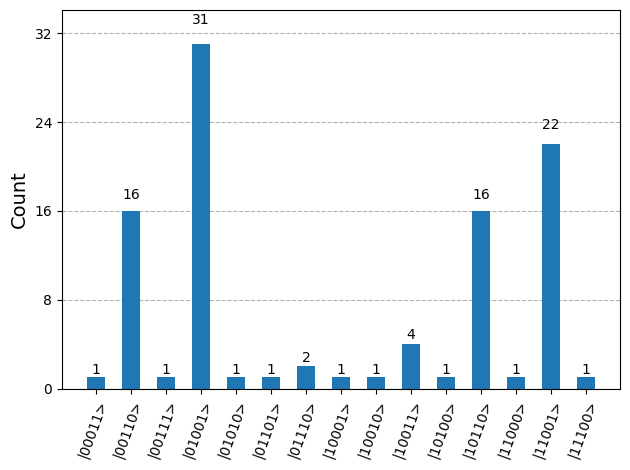

In [11]:
result = objective(graph, n, res.x, final=True)

result.histogram()

|01001>: 31


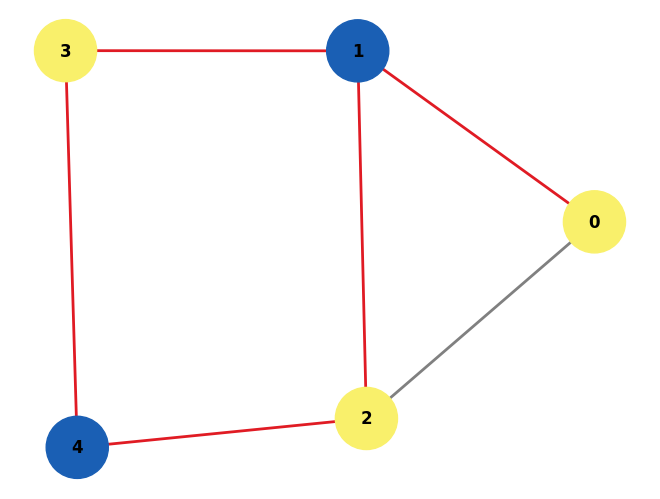

|11001>: 22


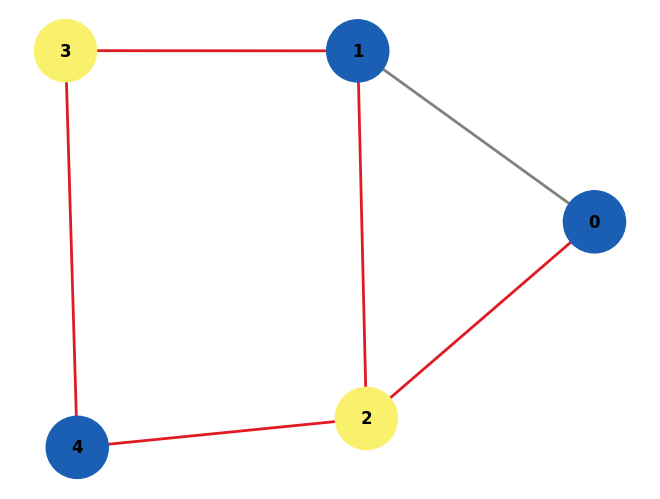

|10110>: 16


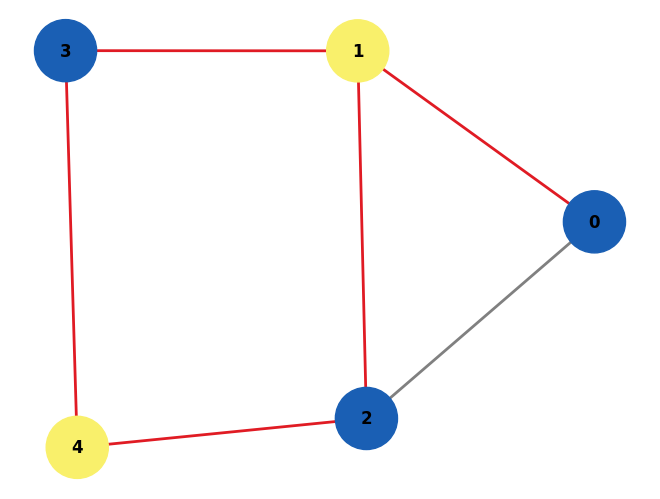

In [12]:
print_n_results = 3
for state, count in sorted(
    result.get().items(),
    key=lambda kv: kv[1],
    reverse=True,
)[:print_n_results]:
    state = f"{state:0{n}b}"
    print(f"|{state}>: {count}")
    plot_graph(graph, state)

# QAOA QUBO - Otimização de Portfólio

$$H(x) = \underbrace{- \sum_{i=1}^n \mu_i x_i}_{\text{Maximizar Retorno}} + \underbrace{q \sum_{i,j} \sigma_{ij} x_i x_j}_{\text{Minimizar Risco}} + \underbrace{\lambda \left( \sum_{i=1}^n x_i - B \right)^2}_{\text{Restrição (Budget)}}$$

## Expansão da penalidade de orçamento e coeficientes do QUBO

Assumimos variáveis binárias $x_i \in \{0,1\}$

Seja $S=\sum_i x_i$. Então:

$$
(S-B)^2 = S^2 - 2BS + B^2.
$$

E

$$
S^2 = \left(\sum_i x_i\right)^2 = \sum_i x_i^2 + 2\sum_{i<j} x_i x_j.
$$

Como $x_i\in\{0,1\}\Rightarrow x_i^2=x_i$, segue:

$$
\left(\sum_i x_i - B\right)^2
= (1-2B)\sum_i x_i \;+\; 2\sum_{i<j} x_i x_j \;+\; B^2.
$$

Substituindo em $H(x)$, obtemos a forma padrão:

$$
H(x)=\sum_i a_i x_i + \sum_{i<j} b_{ij} x_i x_j + \text{constante},
$$

com:

$$
a_i = -\mu_i + \lambda(1-2B),
$$

$$
b_{ij} = q\,\sigma_{ij} + 2\lambda,
$$

$$
\text{constante} = \lambda B^2.
$$

Isso corresponde exatamente ao código:

- `linear[i] = -mu[i] + lambda_*(1 - 2*B)`
- `quad[(i,j)] = q*sigma[i][j] + 2*lambda_`
- `const = lambda_*(B**2)`


##

In [13]:
def portfolio_h_terms(mu, sigma, B, q, lambda_=1):
    n = len(mu)

    linear = [(-mu[i] + lambda_ * (1 - 2 * B)) for i in range(n)]
    quad = {}
    for i in range(n):
        for j in range(i + 1, n):
            quad[(i, j)] = q * sigma[i][j] + 2 * lambda_

    const = lambda_ * (B**2)
    z_terms = {i: 0.0 for i in range(n)}
    zz_terms = {}

    for i, a in enumerate(linear):
        const += 0.5 * a
        z_terms[i] += -0.5 * a

    for (i, j), b in quad.items():
        const += 0.25 * b
        z_terms[i] += -0.25 * b
        z_terms[j] += -0.25 * b
        zz_terms[(i, j)] = zz_terms.get((i, j), 0.0) + 0.25 * b

    return const, z_terms, zz_terms


def portfolio_h_operator(
    mu: list[float],
    sigma: list[list[float]],
    B: int,
    q: float,
    lambda_: float = 1,
):
    n = len(mu)
    const, z_terms, zz_terms = portfolio_h_terms(mu, sigma, B, q, lambda_)

    labels = ["I" * n]
    coeffs = [const]

    for i, c in z_terms.items():
        if abs(c) > 1e-12:
            labels.append(pauli_label(n, z_indices=[i]))
            coeffs.append(c)

    for (i, j), c in zz_terms.items():
        if abs(c) > 1e-12:
            labels.append(pauli_label(n, z_indices=[i, j]))
            coeffs.append(c)

    return SparsePauliOp.from_list(list(zip(labels, coeffs)))

In [14]:
mu = [0.31542042, 0.0571331, 0.11430001, 0.30109367]

sigma = [
    [1.08774352e-03, 2.59532811e-04, 1.80247155e-04, 3.21724369e-04],
    [2.59532811e-04, 4.43192629e-04, 7.43211072e-05, 2.27911525e-04],
    [1.80247155e-04, 7.43211072e-05, 3.89444953e-04, 1.37915422e-04],
    [3.21724369e-04, 2.27911525e-04, 1.37915422e-04, 8.75437564e-04],
]

risk = 0.5
budget = 2

## Circuito Parametrizado

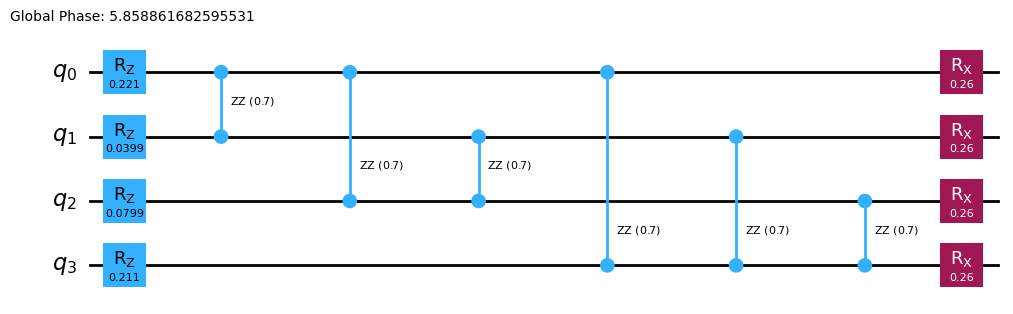

In [15]:
def qaoa_qubo_layer(mu, sigma, budget, risk, qc, qubits, gamma, beta):
    cost_op = portfolio_h_operator(mu, sigma, budget, risk)
    mixer_op = mixer_h(len(mu))

    qc.append(PauliEvolutionGate(cost_op, time=gamma), qubits)
    qc.barrier()
    qc.append(PauliEvolutionGate(mixer_op, time=beta), qubits)


draw(
    partial(qaoa_qubo_layer, mu, sigma, budget, risk, gamma=0.7, beta=0.13),
    len(mu),
    fold=-1,
)

In [16]:
def ansatz_qubo(mu, sigma, budget, risk, qc, qubits, gamma, beta):
    qc.h(qubits)
    for g, b in zip(gamma, beta):
        qaoa_qubo_layer(mu, sigma, budget, risk, qc, qubits, g, b)

## Otimizando os parâmetros    

In [17]:
def objective_qubo(mu, sigma, budget, risk, parameters, final=False):
    p = len(parameters) // 2
    gamma = parameters[p:]
    beta = parameters[:p]
    n = len(mu)

    qc = QuantumCircuit(n)
    ansatz_qubo(mu, sigma, budget, risk, qc, list(range(n)), gamma, beta)

    if final:
        return sample_circuit(qc, 100)

    op = portfolio_h_operator(mu, sigma, budget, risk)
    return expectation_value(qc, op)

In [18]:
p = 4
parameters = [0.5 for _ in range(2 * p)]

res = minimize(
    partial(objective_qubo, mu, sigma, budget, risk),
    parameters,
    method="COBYLA",
)

res

/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


 message: Return from COBYLA because the objective function has been evaluated MAXFUN times.
 success: False
  status: 3
     fun: -0.3859205450106994
       x: [ 2.070e-01  8.004e-01  8.333e-01  4.864e-01  9.548e-01
            6.697e-01  1.697e+00  7.187e-01]
    nfev: 1000
   maxcv: 0.0

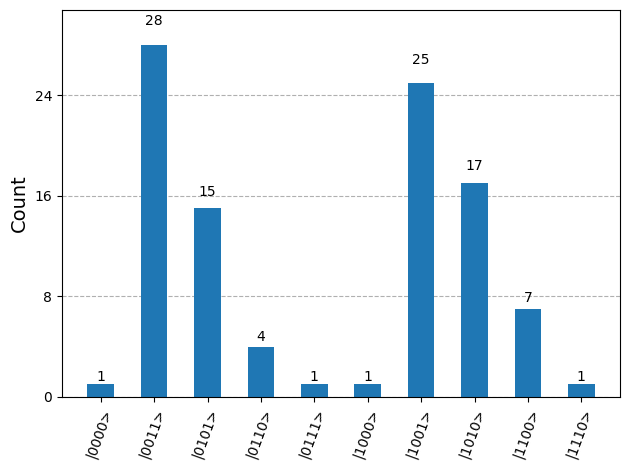

In [19]:
result = objective_qubo(mu, sigma, budget, risk, res.x, final=True)

result.histogram()

In [20]:
for bitstring, count in sorted(
    result.get().items(),
    key=lambda kv: kv[1],
    reverse=True,
):
    bitstring = f"{bitstring:0{len(mu)}b}"
    print(
        f"|{bitstring}>: <H> = {get_cost(bitstring, partial(portfolio_h_operator, mu, sigma, budget, risk)):+.6f}; count = {count} "
    )

|0011>: <H> = -0.415325; count = 28 
|1001>: <H> = -0.616353; count = 25 
|1010>: <H> = -0.429630; count = 17 
|0101>: <H> = -0.358113; count = 15 
|1100>: <H> = -0.372424; count = 7 
|0110>: <H> = -0.171396; count = 4 
|1000>: <H> = +0.684580; count = 1 
|0000>: <H> = +4.000000; count = 1 
|0111>: <H> = +0.527693; count = 1 
|1110>: <H> = +0.513404; count = 1 
